<a href="https://colab.research.google.com/github/adarshdyreddy/Data-Science/blob/main/auto_mpg_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
data= pd.read_csv("/content/auto-mpg (1).csv")

In [ ]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [ ]:
data.shape

(398, 9)

In [ ]:
df=data.drop(['mpg','cylinders'],axis=1)

In [ ]:
df.columns

Index(['displacement', 'horsepower', 'weight', 'acceleration', 'model year',
       'origin', 'car name'],
      dtype='object')

In [ ]:
df.drop_duplicates()

,displacement,horsepower,weight,acceleration,model year,origin,car name
0,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...
393,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,97.0,52.0,2130,24.6,82,2,vw pickup
395,135.0,84.0,2295,11.6,82,1,dodge rampage
396,120.0,79.0,2625,18.6,82,1,ford ranger


In [ ]:
print(df.isnull().sum())

displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [ ]:
df['horsepower'] = df['horsepower'].replace('?', None)
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [ ]:
# Fill missing horsepower values with mean
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

/tmp/ipykernel_1562/2543412204.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


In [ ]:
# Statistical figures of numerical attributes
df.describe()

,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,104.269838,38.199187,846.841774,2.757689,3.697627,0.802055
min,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,148.500000,95.000000,2803.500000,15.500000,76.000000,1.000000
75%,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


<Axes: xlabel='displacement', ylabel='No of Cars'>

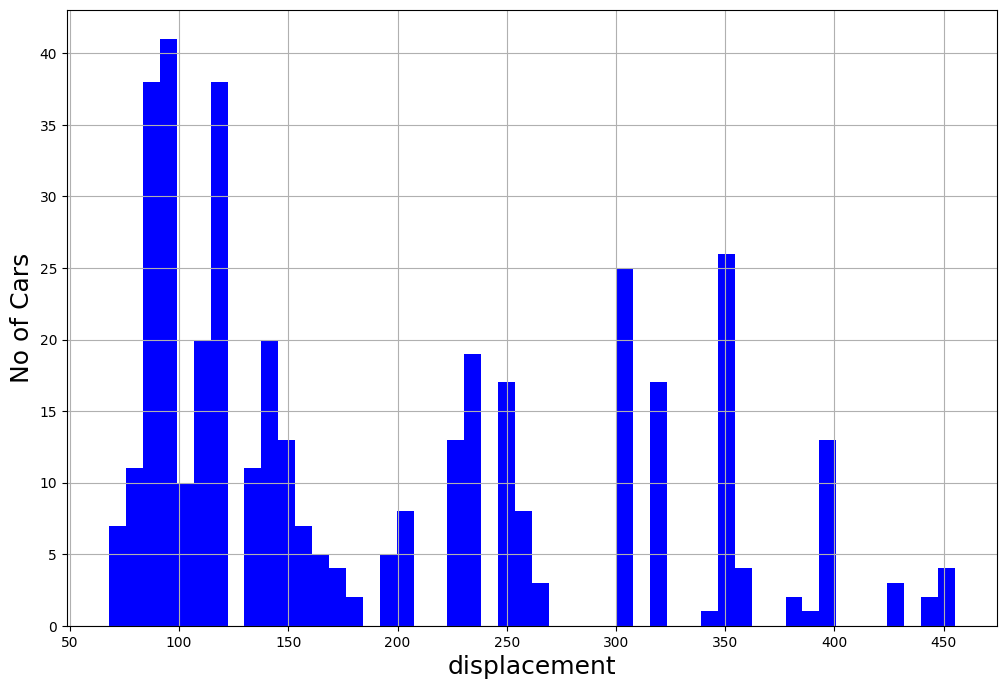

In [ ]:
# MPG distribution
plt.figure(figsize=(12,8))
plt.xlabel('displacement', fontsize=18)
plt.ylabel('No of Cars', fontsize=18)
df['displacement'].hist(bins=50, color='blue')

In [ ]:
# Reload only deleted columns
new_data = pd.read_csv("auto-mpg (1).csv")

df['mpg'] = new_data['mpg']
df['cylinders'] = new_data['cylinders']

print(df.head())

   displacement  horsepower  weight  acceleration  model year  origin  \
0         307.0       130.0    3504          12.0          70       1   
1         350.0       165.0    3693          11.5          70       1   
2         318.0       150.0    3436          11.0          70       1   
3         304.0       150.0    3433          12.0          70       1   
4         302.0       140.0    3449          10.5          70       1   

                    car name   mpg  cylinders  
0  chevrolet chevelle malibu  18.0          8  
1          buick skylark 320  15.0          8  
2         plymouth satellite  18.0          8  
3              amc rebel sst  16.0          8  
4                ford torino  17.0          8  


In [ ]:
print(df.columns)

Index(['displacement', 'horsepower', 'weight', 'acceleration', 'model year',
       'origin', 'car name', 'mpg', 'cylinders'],
      dtype='object')


<Axes: xlabel='MPG', ylabel='No of Cars'>

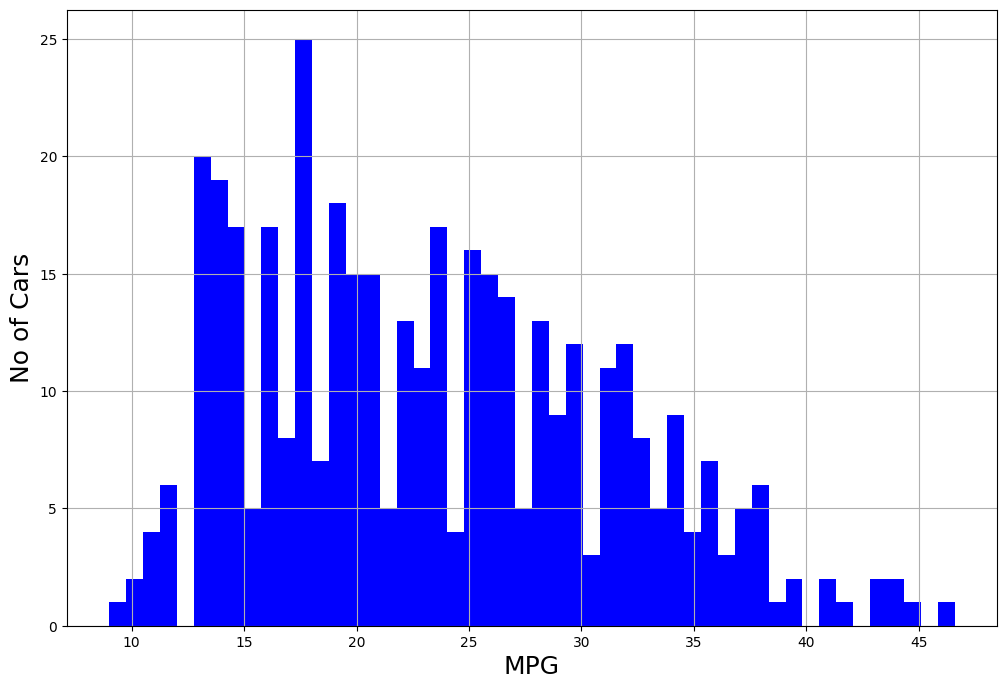

In [ ]:
# MPG distribution
plt.figure(figsize=(12,8))
plt.xlabel('MPG', fontsize=18)
plt.ylabel('No of Cars', fontsize=18)
df['mpg'].hist(bins=50, color='blue')

<Axes: xlabel='cylinders'>

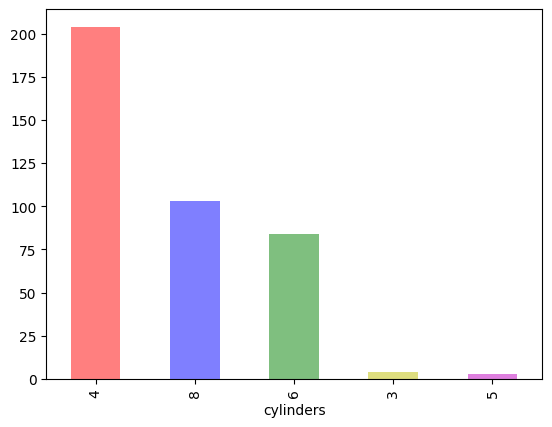

In [ ]:
# Cylinders distribution
alpha_color = 0.5
df['cylinders'].value_counts().plot(kind='bar', color=['r','b','g','y','m'], alpha=alpha_color)

<Axes: xlabel='Horsepower', ylabel='No of Cars'>

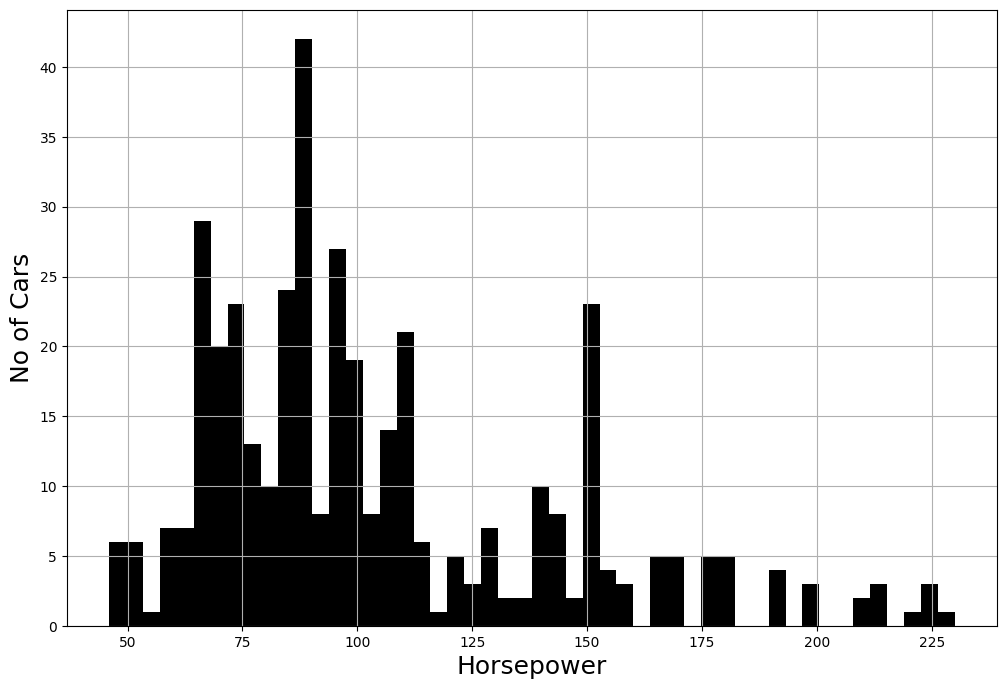

In [ ]:
# Horsepower distribution
plt.figure(figsize=(12,8))
plt.xlabel('Horsepower', fontsize=18)
plt.ylabel('No of Cars', fontsize=18)
df['horsepower'].hist(bins=50, color='black')

<Axes: xlabel='Weight', ylabel='No of Cars'>

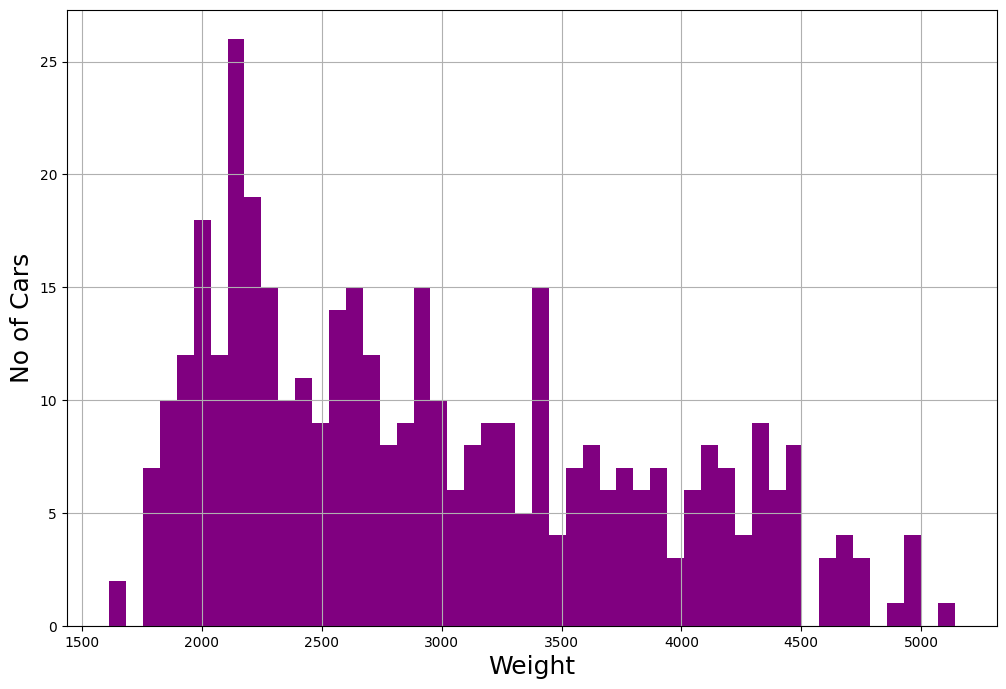

In [ ]:
# Weight distribution
plt.figure(figsize=(12,8))
plt.xlabel('Weight', fontsize=18)
plt.ylabel('No of Cars', fontsize=18)
df['weight'].hist(bins=50, color='purple')

<Axes: xlabel='car name'>

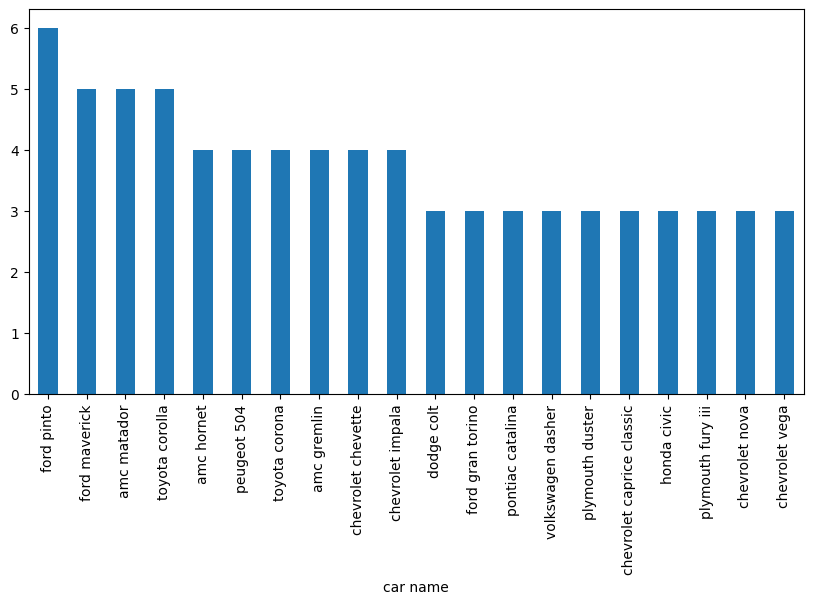

In [ ]:
# Top 20 car names
df['car name'].value_counts().nlargest(20).plot(kind='bar', figsize=(10,5))

<Axes: xlabel='origin'>

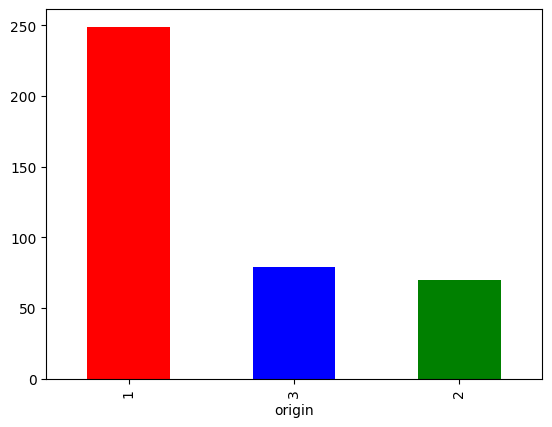

In [ ]:
# Origin distribution
df['origin'].value_counts().plot(kind='bar', color=['r','b','g'])

<Axes: xlabel='model year'>

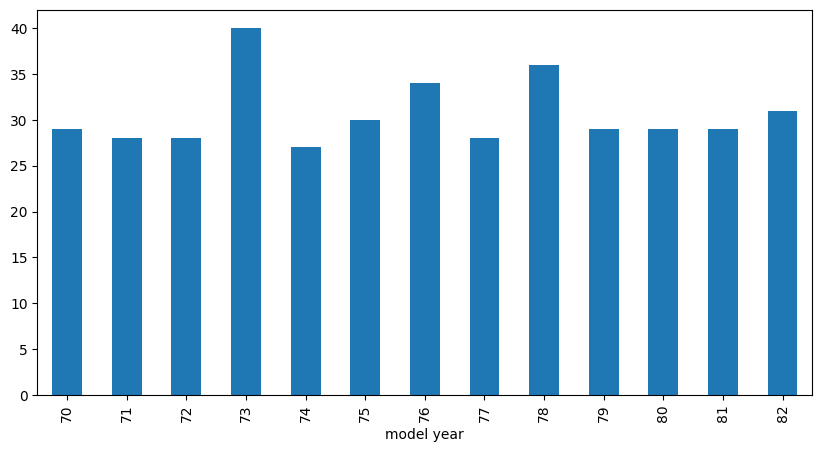

In [ ]:
# Model year distribution
df['model year'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))

Text(0.5, 1.0, 'Average MPG by Cylinders')

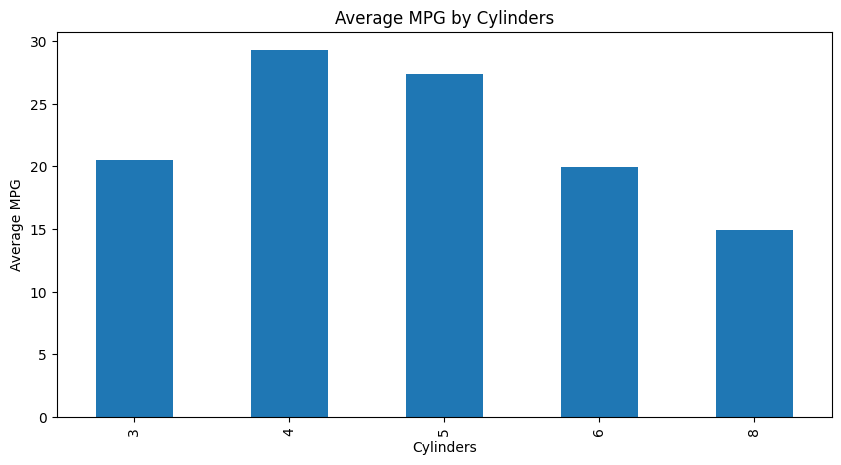

In [ ]:
# Average MPG by cylinders
df.groupby('cylinders')['mpg'].mean().plot(kind='bar', figsize=(10,5))
plt.xlabel('Cylinders')
plt.ylabel('Average MPG')
plt.title('Average MPG by Cylinders')

Text(0.5, 1.0, 'Average MPG by Origin')

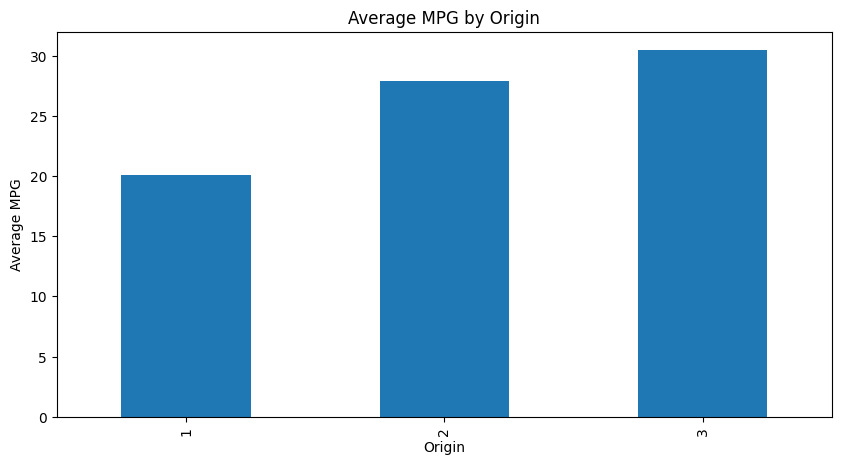

In [ ]:
# Average MPG by origin
df.groupby('origin')['mpg'].mean().plot(kind='bar', figsize=(10,5))
plt.xlabel('Origin')
plt.ylabel('Average MPG')
plt.title('Average MPG by Origin')

Text(0.5, 1.0, 'Correlation Heatmap')

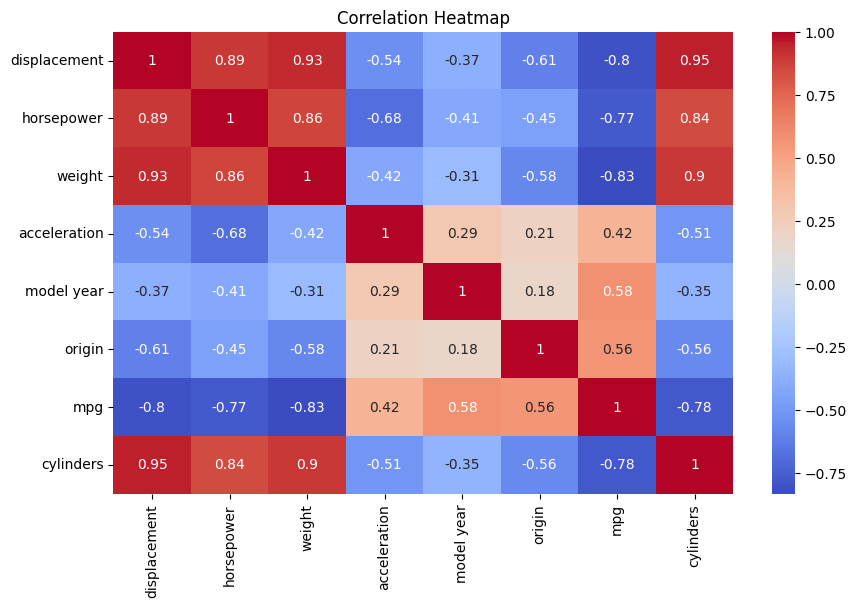

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'MPG vs Horsepower')

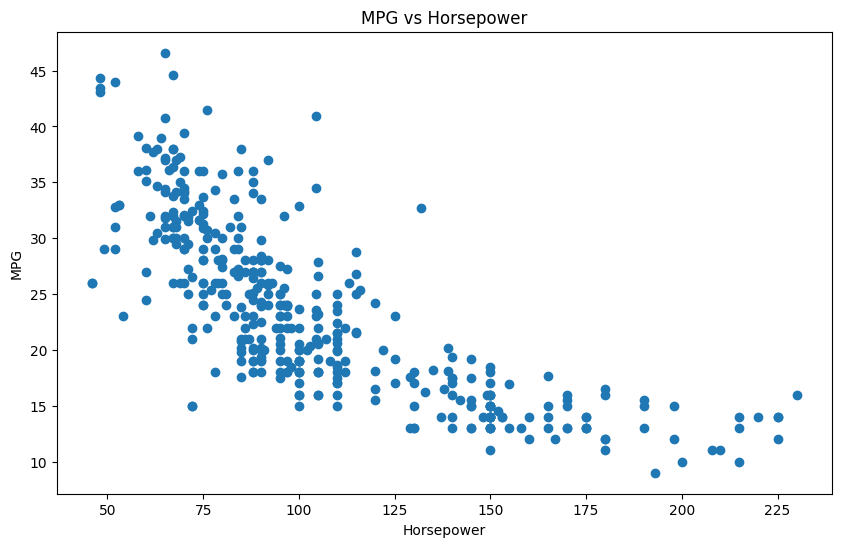

In [ ]:
# MPG vs Horsepower
plt.figure(figsize=(10,6))
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower')

([<matplotlib.patches.Wedge at 0x7cb7dbfe9c70>,
 [Text(-0.03337537233666657, -1.0994935581991323, '4'),
  Text(0.7487151825708861, 0.8058694530678309, '8'),
  Text(-0.7314442124929538, 0.8215773633752106, '6'),
  Text(-1.0878532339276508, 0.16301945108836666, '3'),
  Text(-1.0951959383005017, 0.10269302181786226, '5')],
 [Text(-0.018204748547272675, -0.5997237590177085, '51.3%'),
  Text(0.40839009958411965, 0.4395651562188168, '25.9%'),
  Text(-0.398969570450702, 0.4481331072955694, '21.1%'),
  Text(-0.5933744912332639, 0.08891970059365453, '1.0%'),
  Text(-0.5973796027093645, 0.05601437553701577, '0.8%')])

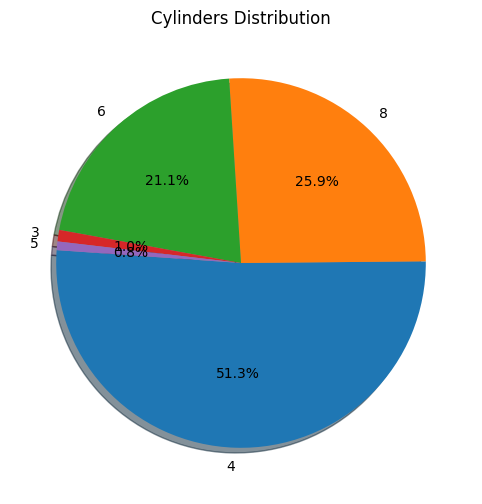

In [ ]:
cylinder_c = df['cylinders'].value_counts()
plt.figure(figsize=(12,6))
plt.title('Cylinders Distribution')
plt.pie(cylinder_c, labels=cylinder_c.index, autopct='%1.1f%%', startangle=176, shadow=True)

In [ ]:
# Conclusion

# From the Auto MPG dataset analysis, we observed that fuel efficiency (MPG)
# is highly affected by factors such as horsepower, weight, and cylinders.
# Cars with lower weight and fewer cylinders generally provide better mileage.
# The analysis also showed differences in car origins and model years.
# Visualization techniques like histograms, bar charts, pie charts, scatter plots,
# and heatmaps helped in understanding the dataset clearly and identifying
# relationships between different automobile features.